
# Inflation Forecasting Using Food and Energy Price Indicators

## Problem Statement 19
Predict consumer price inflation using food prices, fuel prices, crude oil prices, and commodity price indices.

**Target variable**
- `CPI_General_Inflation`

**Core predictor family used in this notebook**
- `Food_Price_Index`
- `Fuel_Light_Index`
- `Crude_Oil_Price`
- `Commodity_Price_Index`
- Lagged and rolling features engineered from the above series and from past CPI inflation

**Official sources behind the cleaned dataset**
- Ministry of Statistics and Programme Implementation (MoSPI)
- Reserve Bank of India / linked market series already stored in the project dataset

This notebook is built to be presentation-ready:
- clean data story
- explicit feature engineering
- transparent model comparison
- time-aware validation
- readable plots and final takeaways



## Notebook Roadmap

1. Load the cleaned monthly dataset and run data-quality checks.
2. Visualize CPI inflation and the four assignment indicators.
3. Engineer time-series features without leaking future information.
4. Compare several forecasting models using chronological validation.
5. Score the final 24 months with a **walk-forward one-step-ahead** holdout backtest.
6. Inspect the best model and export the main artifacts.

**Important note**
This notebook stays faithful to the assignment statement. Even though the project dataset contains extra columns, the model only uses the variables named in the problem statement plus engineered lag and rolling features.


In [12]:

from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.frameon'] = False
plt.rcParams['figure.dpi'] = 120

TARGET_COL = 'CPI_General_Inflation'
BASE_FEATURES = [
    'Food_Price_Index',
    'Fuel_Light_Index',
    'Crude_Oil_Price',
    'Commodity_Price_Index',
]

def resolve_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / 'Mayur',
        Path.cwd().parent / 'Mayur',
    ]
    for candidate in candidates:
        if (candidate / 'dataset' / 'inflation_forecasting_dataset.csv').exists():
            return candidate
    raise FileNotFoundError('Could not locate the Mayur project directory from the current working directory.')

PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / 'dataset' / 'inflation_forecasting_dataset.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset path: {DATA_PATH}')
print(f'Results directory: {RESULTS_DIR}')
print(f'XGBoost available: {HAS_XGBOOST}')


Project root: c:\Development\TSFA\TimeSeries\Mayur
Dataset path: c:\Development\TSFA\TimeSeries\Mayur\dataset\inflation_forecasting_dataset.csv
Results directory: c:\Development\TSFA\TimeSeries\Mayur\results
XGBoost available: True



## 1. Load And Validate The Dataset

We start with the cleaned monthly dataset created by the preprocessing pipeline. The checks below confirm:
- monthly continuity
- no duplicate year-month pairs
- no missing values in the modeling columns
- the exact date range covered by the assignment dataset


In [13]:

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

modeling_columns = ['Date', 'Year', 'Month', TARGET_COL] + BASE_FEATURES
assignment_df = df.loc[:, modeling_columns].copy()

expected_dates = pd.date_range(assignment_df['Date'].min(), assignment_df['Date'].max(), freq='MS')
quality_summary = pd.DataFrame({
    'Check': [
        'Rows',
        'Start month',
        'End month',
        'Duplicate year-month rows',
        'Total missing cells',
        'Continuous monthly coverage',
    ],
    'Value': [
        len(assignment_df),
        assignment_df['Date'].min().strftime('%Y-%m'),
        assignment_df['Date'].max().strftime('%Y-%m'),
        int(assignment_df.duplicated(['Year', 'Month']).sum()),
        int(assignment_df.isna().sum().sum()),
        bool(assignment_df['Date'].reset_index(drop=True).equals(pd.Series(expected_dates))),
    ],
})

print('Head of the cleaned assignment dataset:')
display(assignment_df.head())
print('\nData quality summary:')
display(quality_summary)
print('\nDescriptive statistics for the target and core predictors:')
display(assignment_df.drop(columns='Date').describe().T.round(3))


Head of the cleaned assignment dataset:


,Date,Year,Month,CPI_General_Inflation,Food_Price_Index,Fuel_Light_Index,Crude_Oil_Price,Commodity_Price_Index
0,2012-01-01,2012,1,6.26,93.4,96.4,110.98,144.1561
1,2012-02-01,2012,2,8.03,93.9,96.8,122.66,148.0367
2,2012-03-01,2012,3,9.05,95.2,97.1,122.88,141.9021
3,2012-04-01,2012,4,9.76,97.4,98.1,119.47,141.2917
4,2012-05-01,2012,5,9.80,98.4,98.6,101.43,128.3789



Data quality summary:


,Check,Value
0,Rows,168
1,Start month,2012-01
2,End month,2025-12
3,Duplicate year-month rows,0
4,Total missing cells,0
5,Continuous monthly coverage,True



Descriptive statistics for the target and core predictors:


,count,mean,std,min,25%,50%,75%,max
Year,168.0,2018.500,4.043,2012.000,2015.000,2018.500,2022.000,2025.000
Month,168.0,6.500,3.462,1.000,3.750,6.500,9.250,12.000
CPI_General_Inflation,168.0,5.529,2.233,0.250,4.042,5.255,6.855,10.890
Food_Price_Index,168.0,148.953,30.272,93.400,127.950,139.550,173.800,211.100
Fuel_Light_Index,168.0,142.431,27.391,96.400,120.025,139.700,174.900,186.500
Crude_Oil_Price,168.0,74.965,22.821,26.350,57.315,71.950,89.995,122.880
Commodity_Price_Index,168.0,101.038,21.187,60.898,84.607,98.704,113.653,148.506


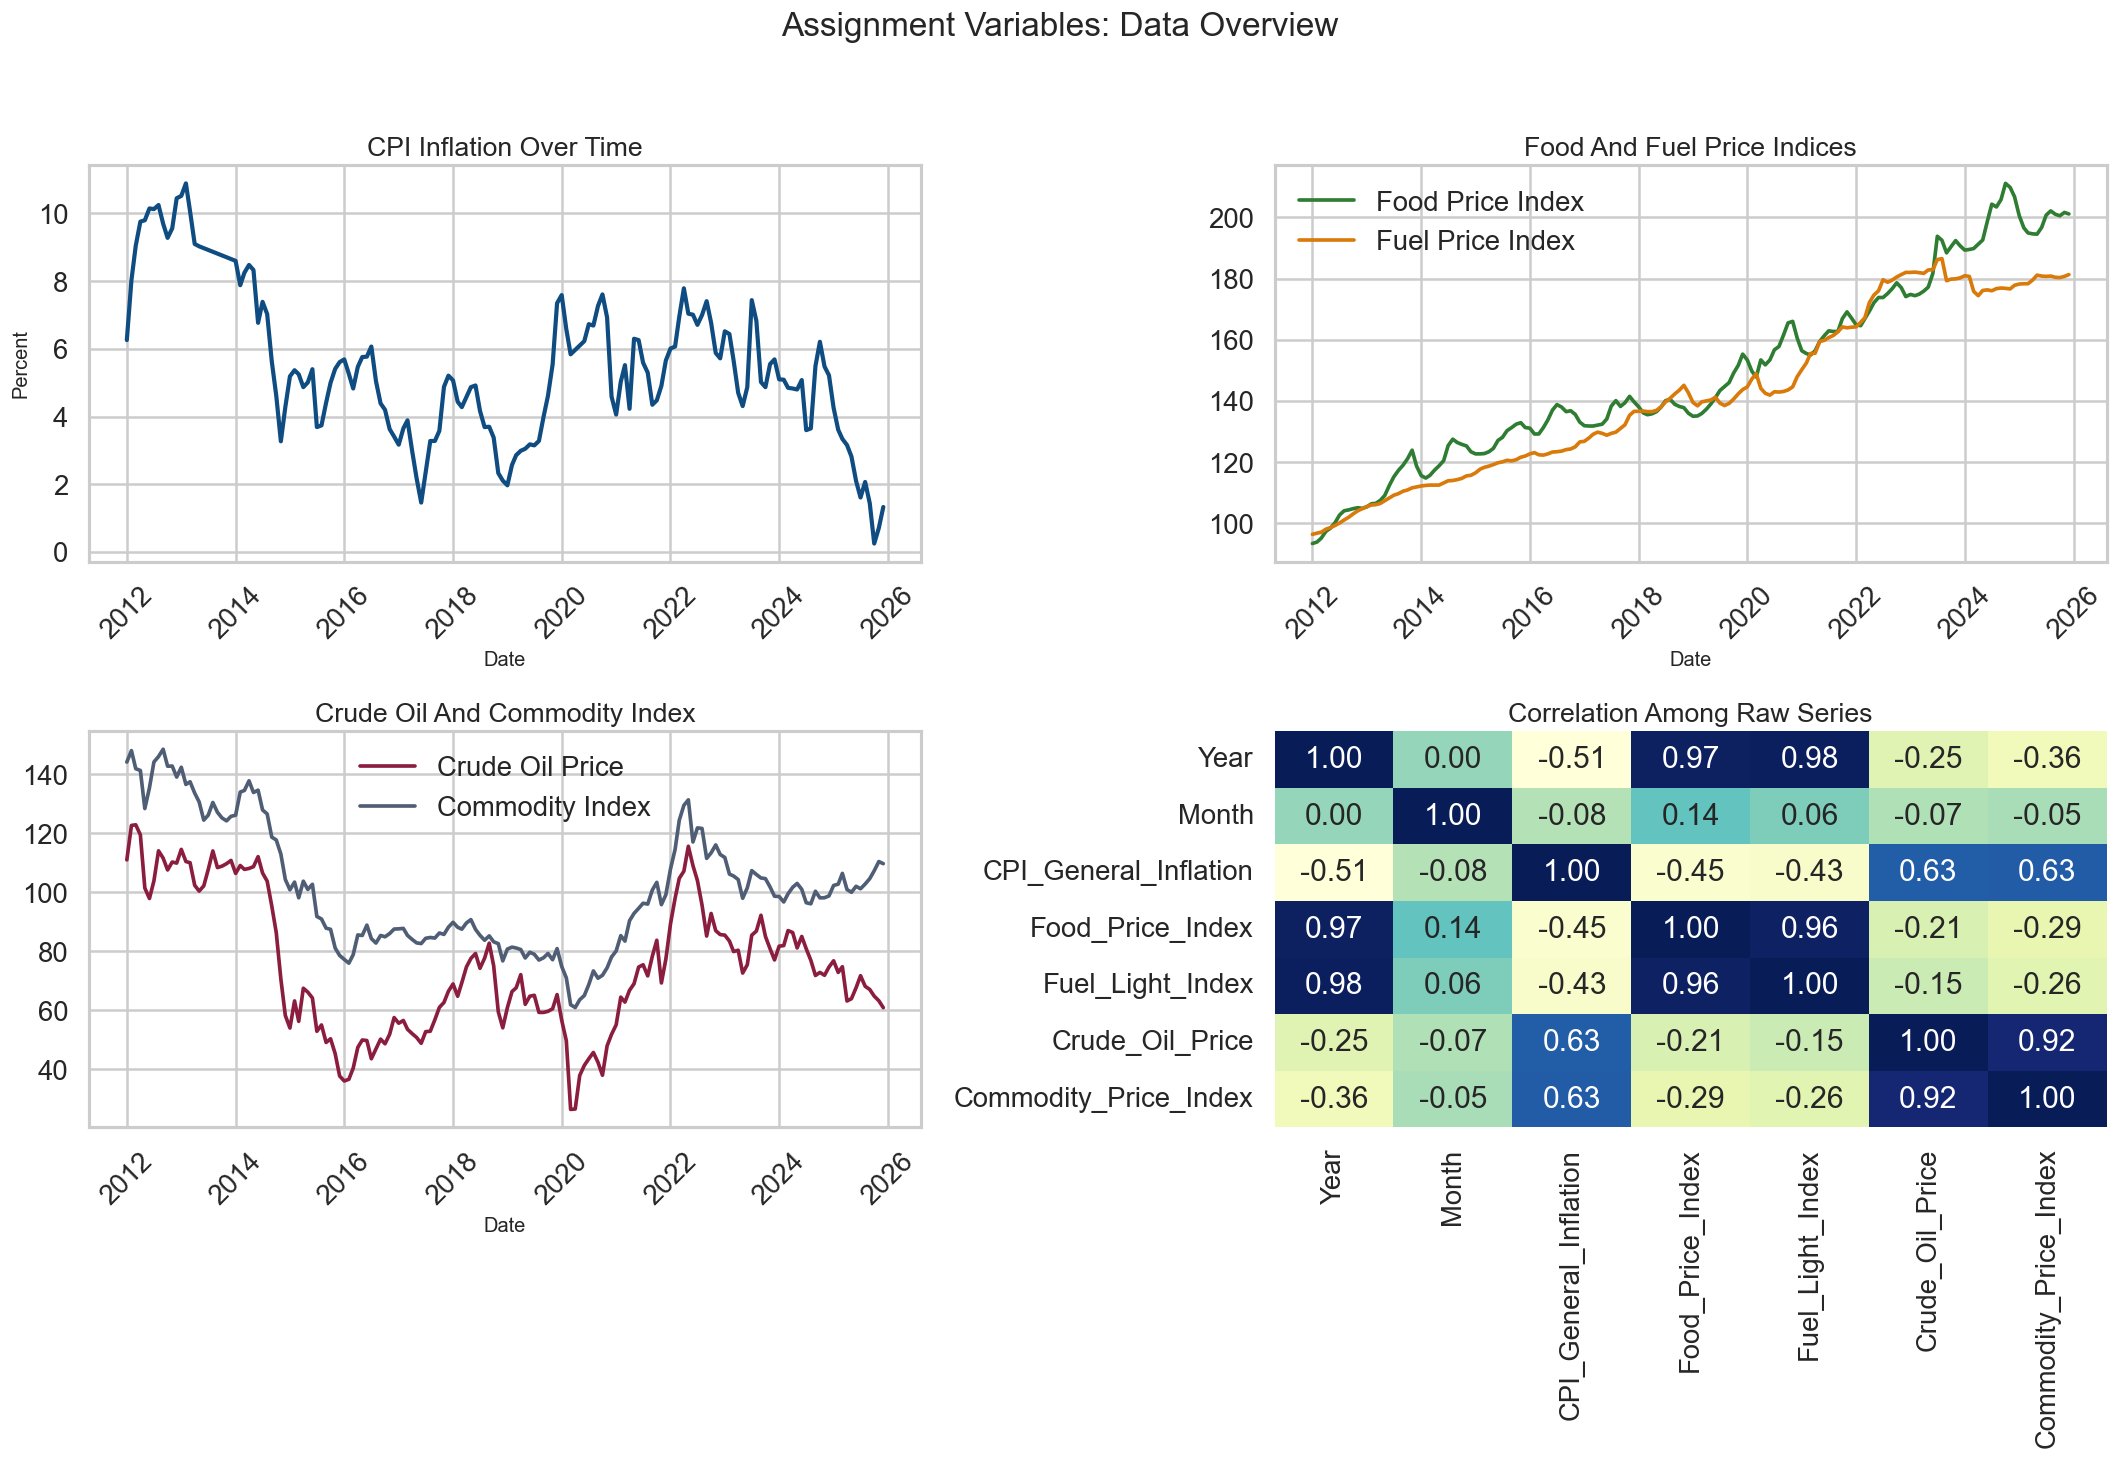

In [14]:

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].plot(assignment_df['Date'], assignment_df[TARGET_COL], color='#0f4c81', linewidth=2.5)
axes[0, 0].set_title('CPI Inflation Over Time')
axes[0, 0].set_ylabel('Percent')

axes[0, 1].plot(assignment_df['Date'], assignment_df['Food_Price_Index'], label='Food Price Index', color='#2f7d32', linewidth=2.2)
axes[0, 1].plot(assignment_df['Date'], assignment_df['Fuel_Light_Index'], label='Fuel Price Index', color='#d97a0b', linewidth=2.2)
axes[0, 1].set_title('Food And Fuel Price Indices')
axes[0, 1].legend()

axes[1, 0].plot(assignment_df['Date'], assignment_df['Crude_Oil_Price'], label='Crude Oil Price', color='#8b1e3f', linewidth=2.2)
axes[1, 0].plot(assignment_df['Date'], assignment_df['Commodity_Price_Index'], label='Commodity Index', color='#4f5d75', linewidth=2.2)
axes[1, 0].set_title('Crude Oil And Commodity Index')
axes[1, 0].legend()

correlation_frame = assignment_df.drop(columns='Date').corr(numeric_only=True)
sns.heatmap(correlation_frame, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Correlation Among Raw Series')

for ax in axes.flat[:3]:
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Assignment Variables: Data Overview', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()



## 2. Feature Engineering

The raw variables from the assignment are useful, but time-series models usually improve when we also capture momentum, persistence, and seasonality.

The feature block below adds:
- lagged CPI inflation values
- lagged values of food, fuel, crude oil, and commodity series
- rolling mean and rolling volatility of CPI inflation
- month-over-month changes in the four exogenous indicators
- seasonal month encodings using sine and cosine terms

All rolling statistics are shifted so that the model never sees future information.


In [15]:

def build_feature_frame(source_df: pd.DataFrame):
    data = source_df.copy()

    for lag in [1, 2, 3, 6, 12]:
        data[f'CPI_Inflation_Lag_{lag}'] = data[TARGET_COL].shift(lag)

    for feature in BASE_FEATURES:
        for lag in [1, 3, 6]:
            data[f'{feature}_Lag_{lag}'] = data[feature].shift(lag)
        for period in [1, 3]:
            data[f'{feature}_Pct_Change_{period}'] = data[feature].pct_change(period) * 100

    for window in [3, 6, 12]:
        data[f'CPI_Rolling_Mean_{window}'] = data[TARGET_COL].shift(1).rolling(window).mean()
        data[f'CPI_Rolling_Std_{window}'] = data[TARGET_COL].shift(1).rolling(window).std()

    data['Month_Sin'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['Month_Cos'] = np.cos(2 * np.pi * data['Month'] / 12)

    feature_df = data.dropna().reset_index(drop=True)
    feature_columns = [
        col for col in feature_df.columns
        if col not in ['Date', 'Year', 'Month', TARGET_COL]
    ]
    return feature_df, feature_columns

feature_df, feature_columns = build_feature_frame(assignment_df)

feature_preview = pd.DataFrame({
    'Feature': feature_columns,
    'Family': [
        'Raw Indicator' if feature in BASE_FEATURES else
        'Target Lag' if feature.startswith('CPI_Inflation_Lag_') else
        'Indicator Lag' if '_Lag_' in feature else
        'Indicator Change' if '_Pct_Change_' in feature else
        'Target Rolling Statistic' if feature.startswith('CPI_Rolling_') else
        'Seasonality'
        for feature in feature_columns
    ]
})

print(f'Modeling rows after feature engineering: {len(feature_df)}')
print(f'Number of modeling features: {len(feature_columns)}')
display(feature_preview.groupby('Family').size().reset_index(name='Feature Count'))
display(feature_df[['Date', TARGET_COL] + feature_columns[:8]].head())


Modeling rows after feature engineering: 156
Number of modeling features: 37


,Family,Feature Count
0,Indicator Change,8
1,Indicator Lag,12
2,Raw Indicator,4
3,Seasonality,2
4,Target Lag,5
5,Target Rolling Statistic,6


,Date,CPI_General_Inflation,Food_Price_Index,Fuel_Light_Index,Crude_Oil_Price,Commodity_Price_Index,CPI_Inflation_Lag_1,CPI_Inflation_Lag_2,CPI_Inflation_Lag_3,CPI_Inflation_Lag_6
0,2013-01-01,10.52,105.4,105.5,114.54,142.3956,10.45,9.56,9.28,10.13
1,2013-02-01,10.89,106.4,106.0,110.42,136.5666,10.52,10.45,9.56,10.25
2,2013-03-01,10.06,106.5,106.1,110.02,137.4762,10.89,10.52,10.45,9.70
3,2013-04-01,9.10,107.5,106.5,102.37,133.6316,10.06,10.89,10.52,9.28
4,2013-05-01,9.03,109.1,107.4,100.39,130.6295,9.10,10.06,10.89,9.56


,Slice,Rows,Start,End
0,Training window,132,2013-01,2023-12
1,Walk-forward holdout window,24,2024-01,2025-12


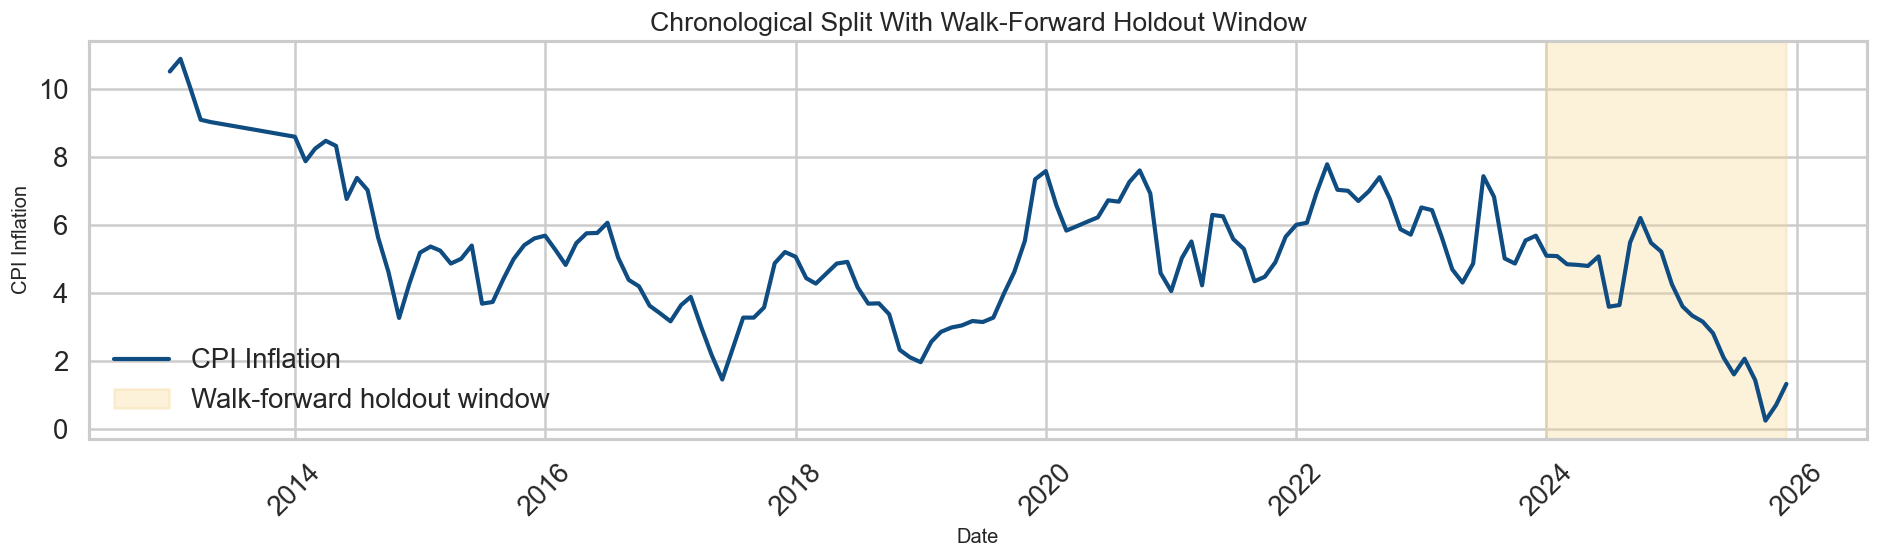

In [16]:

TEST_HORIZON = 24
CV_SPLITS = 4
CV_TEST_SIZE = 12

X = feature_df[feature_columns].copy()
y = feature_df[TARGET_COL].copy()
dates = feature_df['Date'].copy()

test_start_idx = len(X) - TEST_HORIZON
X_train = X.iloc[:test_start_idx].copy()
X_test = X.iloc[test_start_idx:].copy()
y_train = y.iloc[:test_start_idx].copy()
y_test = y.iloc[test_start_idx:].copy()
dates_train = dates.iloc[:test_start_idx].copy()
dates_test = dates.iloc[test_start_idx:].copy()

split_summary = pd.DataFrame({
    'Slice': ['Training window', 'Walk-forward holdout window'],
    'Rows': [len(X_train), len(X_test)],
    'Start': [dates_train.min().strftime('%Y-%m'), dates_test.min().strftime('%Y-%m')],
    'End': [dates_train.max().strftime('%Y-%m'), dates_test.max().strftime('%Y-%m')],
})

display(split_summary)

plt.figure(figsize=(16, 5))
plt.plot(feature_df['Date'], feature_df[TARGET_COL], color='#0f4c81', linewidth=2.5, label='CPI Inflation')
plt.axvspan(dates_test.min(), dates_test.max(), color='#f7d794', alpha=0.35, label='Walk-forward holdout window')
plt.title('Chronological Split With Walk-Forward Holdout Window')
plt.xlabel('Date')
plt.ylabel('CPI Inflation')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 3. Model Registry

We use a mix of simple baselines, regularized linear models, and tree-based ensemble models.

This makes the comparison easy to explain in class:
- **Naive baselines** show what happens if we simply reuse old CPI inflation values.
- **Linear models** test whether the relationship is mostly additive and stable.
- **Tree ensembles** test whether non-linear interactions improve forecasting accuracy.
- **Voting ensemble** blends strong but different models to smooth their errors.

**Backtest note**
The final test score is now a strict **walk-forward one-step-ahead** evaluation. That means the model only uses information available up to each forecast month.


In [17]:

class LagFeatureNaiveRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, lag_feature: str):
        self.lag_feature = lag_feature

    def fit(self, X, y):
        return self

    def predict(self, X):
        return np.asarray(X[self.lag_feature], dtype=float)


def scaled_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model),
    ])


def tree_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model),
    ])


model_registry = {
    'Last Value Naive': LagFeatureNaiveRegressor('CPI_Inflation_Lag_1'),
    'Seasonal Naive': LagFeatureNaiveRegressor('CPI_Inflation_Lag_12'),
    'Linear Regression': scaled_pipeline(LinearRegression()),
    'Ridge Regression': scaled_pipeline(Ridge(alpha=1.0)),
    'Lasso Regression': scaled_pipeline(Lasso(alpha=0.01, max_iter=20000)),
    'ElasticNet': scaled_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.4, max_iter=20000)),
    'KNN Regressor': scaled_pipeline(KNeighborsRegressor(n_neighbors=5, weights='distance')),
    'SVR': scaled_pipeline(SVR(C=5.0, epsilon=0.1, kernel='rbf')),
    'Random Forest': tree_pipeline(
        RandomForestRegressor(
            n_estimators=250,
            max_depth=8,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1,
        )
    ),
    'Gradient Boosting': tree_pipeline(
        GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            random_state=42,
        )
    ),
}

if HAS_XGBOOST:
    model_registry['XGBoost'] = tree_pipeline(
        xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=250,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=1,
        )
    )

ensemble_estimators = [
    ('ridge', scaled_pipeline(Ridge(alpha=1.0))),
    ('lasso', scaled_pipeline(Lasso(alpha=0.01, max_iter=20000))),
    ('gb', tree_pipeline(GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42,
    ))),
]

if HAS_XGBOOST:
    ensemble_estimators.append(
        ('xgboost', tree_pipeline(xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=1,
        )))
    )
else:
    ensemble_estimators.append(
        ('random_forest', tree_pipeline(RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=1,
        )))
    )

model_registry['Voting Ensemble'] = VotingRegressor(estimators=ensemble_estimators)

model_notes = pd.DataFrame([
    ('Last Value Naive', 'Baseline', 'Predict next CPI inflation with the previous month value.'),
    ('Seasonal Naive', 'Baseline', 'Predict next CPI inflation with the same month last year.'),
    ('Linear Regression', 'Linear', 'Simple linear benchmark across all engineered features.'),
    ('Ridge Regression', 'Linear', 'Linear model with L2 shrinkage to control overfitting.'),
    ('Lasso Regression', 'Linear', 'Linear model with L1 shrinkage for sparse coefficients.'),
    ('ElasticNet', 'Linear', 'Combines L1 and L2 regularization.'),
    ('KNN Regressor', 'Distance-Based', 'Predict from nearby months in feature space.'),
    ('SVR', 'Kernel Method', 'Fits a flexible margin around the time-series pattern.'),
    ('Random Forest', 'Tree Ensemble', 'Bagged trees for non-linear relationships.'),
    ('Gradient Boosting', 'Tree Ensemble', 'Boosted trees fitted stage by stage.'),
    ('XGBoost', 'Advanced Ensemble', 'Extreme gradient boosting for stronger tabular performance.'),
    ('Voting Ensemble', 'Ensemble', 'Average of strong linear and non-linear models.'),
], columns=['Model', 'Family', 'What It Is Doing'])

if not HAS_XGBOOST:
    model_notes = model_notes[model_notes['Model'] != 'XGBoost']

print(f'Total models compared: {len(model_registry)}')
display(model_notes)


Total models compared: 12


,Model,Family,What It Is Doing
0,Last Value Naive,Baseline,Predict next CPI inflation with the previous m...
1,Seasonal Naive,Baseline,Predict next CPI inflation with the same month...
2,Linear Regression,Linear,Simple linear benchmark across all engineered ...
3,Ridge Regression,Linear,Linear model with L2 shrinkage to control over...
4,Lasso Regression,Linear,Linear model with L1 shrinkage for sparse coef...
5,ElasticNet,Linear,Combines L1 and L2 regularization.
6,KNN Regressor,Distance-Based,Predict from nearby months in feature space.
7,SVR,Kernel Method,Fits a flexible margin around the time-series ...
8,Random Forest,Tree Ensemble,Bagged trees for non-linear relationships.
9,Gradient Boosting,Tree Ensemble,Boosted trees fitted stage by stage.


In [18]:

def regression_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred) * 100,
        'R2': r2_score(y_true, y_pred),
    }


def walk_forward_one_step_predictions(estimator, X, y, forecast_indices):
    predictions = []
    for idx in forecast_indices:
        step_model = clone(estimator)
        step_model.fit(X.iloc[:idx], y.iloc[:idx])
        step_pred = step_model.predict(X.iloc[[idx]])[0]
        predictions.append(float(step_pred))
    return np.asarray(predictions, dtype=float)


def evaluate_model(name, estimator, X, y, dates, test_start_idx, splitter):
    X_train = X.iloc[:test_start_idx]
    y_train = y.iloc[:test_start_idx]
    y_test = y.iloc[test_start_idx:]
    dates_test = dates.iloc[test_start_idx:]

    fold_rows = []
    for fold, (train_idx, val_idx) in enumerate(splitter.split(X_train), start=1):
        fold_model = clone(estimator)
        fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_pred = fold_model.predict(X_train.iloc[val_idx])
        fold_metrics = regression_metrics(y_train.iloc[val_idx], val_pred)
        fold_metrics['Fold'] = fold
        fold_rows.append(fold_metrics)

    cv_frame = pd.DataFrame(fold_rows)

    forecast_indices = list(range(test_start_idx, len(X)))
    test_pred = walk_forward_one_step_predictions(estimator, X, y, forecast_indices)
    test_metrics = regression_metrics(y_test, test_pred)

    final_model = clone(estimator)
    final_model.fit(X_train, y_train)

    prediction_frame = pd.DataFrame({
        'Date': dates_test,
        'Actual': y_test.values,
        'Predicted': test_pred,
    })

    summary = {
        'Model': name,
        'CV RMSE Mean': cv_frame['RMSE'].mean(),
        'CV RMSE Std': cv_frame['RMSE'].std(ddof=0),
        'CV MAE Mean': cv_frame['MAE'].mean(),
        'Test RMSE': test_metrics['RMSE'],
        'Test MAE': test_metrics['MAE'],
        'Test MAPE (%)': test_metrics['MAPE'],
        'Test R2': test_metrics['R2'],
    }
    return summary, cv_frame, final_model, prediction_frame


ts_cv = TimeSeriesSplit(n_splits=CV_SPLITS, test_size=CV_TEST_SIZE)

summary_rows = []
cv_results = {}
trained_models = {}
test_predictions = {}

for model_name, estimator in model_registry.items():
    summary, cv_frame, fitted_model, prediction_frame = evaluate_model(
        model_name,
        estimator,
        X,
        y,
        dates,
        test_start_idx,
        ts_cv,
    )
    summary_rows.append(summary)
    cv_results[model_name] = cv_frame
    trained_models[model_name] = fitted_model
    test_predictions[model_name] = prediction_frame

leaderboard = (
    pd.DataFrame(summary_rows)
    .sort_values(['Test RMSE', 'CV RMSE Mean', 'Test MAE'])
    .reset_index(drop=True)
)
leaderboard.index = leaderboard.index + 1

print('Model leaderboard ranked by walk-forward holdout RMSE:')
display(
    leaderboard.style.format({
        'CV RMSE Mean': '{:.3f}',
        'CV RMSE Std': '{:.3f}',
        'CV MAE Mean': '{:.3f}',
        'Test RMSE': '{:.3f}',
        'Test MAE': '{:.3f}',
        'Test MAPE (%)': '{:.2f}',
        'Test R2': '{:.3f}',
    })
)


Model leaderboard ranked by walk-forward holdout RMSE:


,Model,CV RMSE Mean,CV RMSE Std,CV MAE Mean,Test RMSE,Test MAE,Test MAPE (%),Test R2
1,Lasso Regression,0.740,0.258,0.626,0.619,0.430,31.44,0.863
2,ElasticNet,0.943,0.450,0.826,0.621,0.449,32.70,0.862
3,Ridge Regression,1.125,0.589,1.025,0.645,0.488,34.22,0.851
4,Last Value Naive,0.836,0.180,0.638,0.711,0.551,38.07,0.819
5,Linear Regression,1.454,0.700,1.260,0.720,0.531,33.75,0.814
6,Voting Ensemble,0.848,0.210,0.715,0.722,0.550,41.76,0.813
7,SVR,1.060,0.082,0.931,0.791,0.665,47.72,0.776
8,Gradient Boosting,0.956,0.215,0.802,0.835,0.637,50.53,0.750
9,Random Forest,1.012,0.159,0.852,0.872,0.684,53.70,0.728
10,XGBoost,0.982,0.205,0.855,0.920,0.734,54.96,0.697


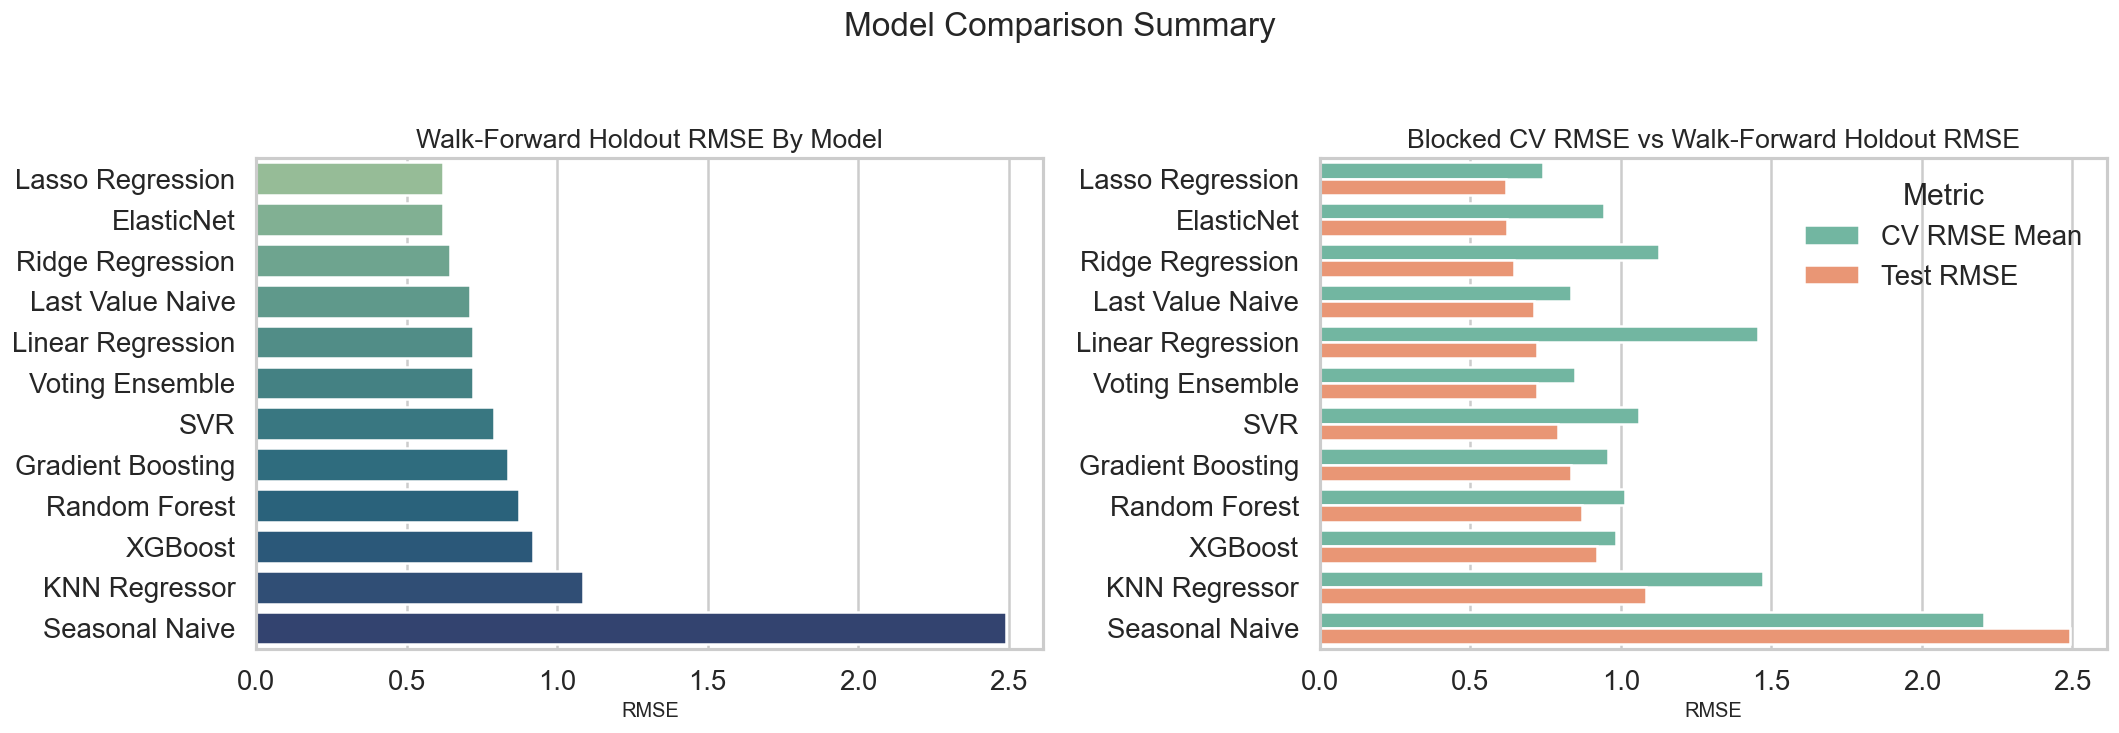

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=leaderboard, y='Model', x='Test RMSE', palette='crest', ax=axes[0])
axes[0].set_title('Walk-Forward Holdout RMSE By Model')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('')

plot_frame = leaderboard.melt(
    id_vars='Model',
    value_vars=['CV RMSE Mean', 'Test RMSE'],
    var_name='Metric',
    value_name='RMSE'
)
sns.barplot(data=plot_frame, y='Model', x='RMSE', hue='Metric', palette='Set2', ax=axes[1])
axes[1].set_title('Blocked CV RMSE vs Walk-Forward Holdout RMSE')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')
axes[1].legend(title='Metric')

plt.suptitle('Model Comparison Summary', fontsize=20, y=1.03)
plt.tight_layout()
plt.show()


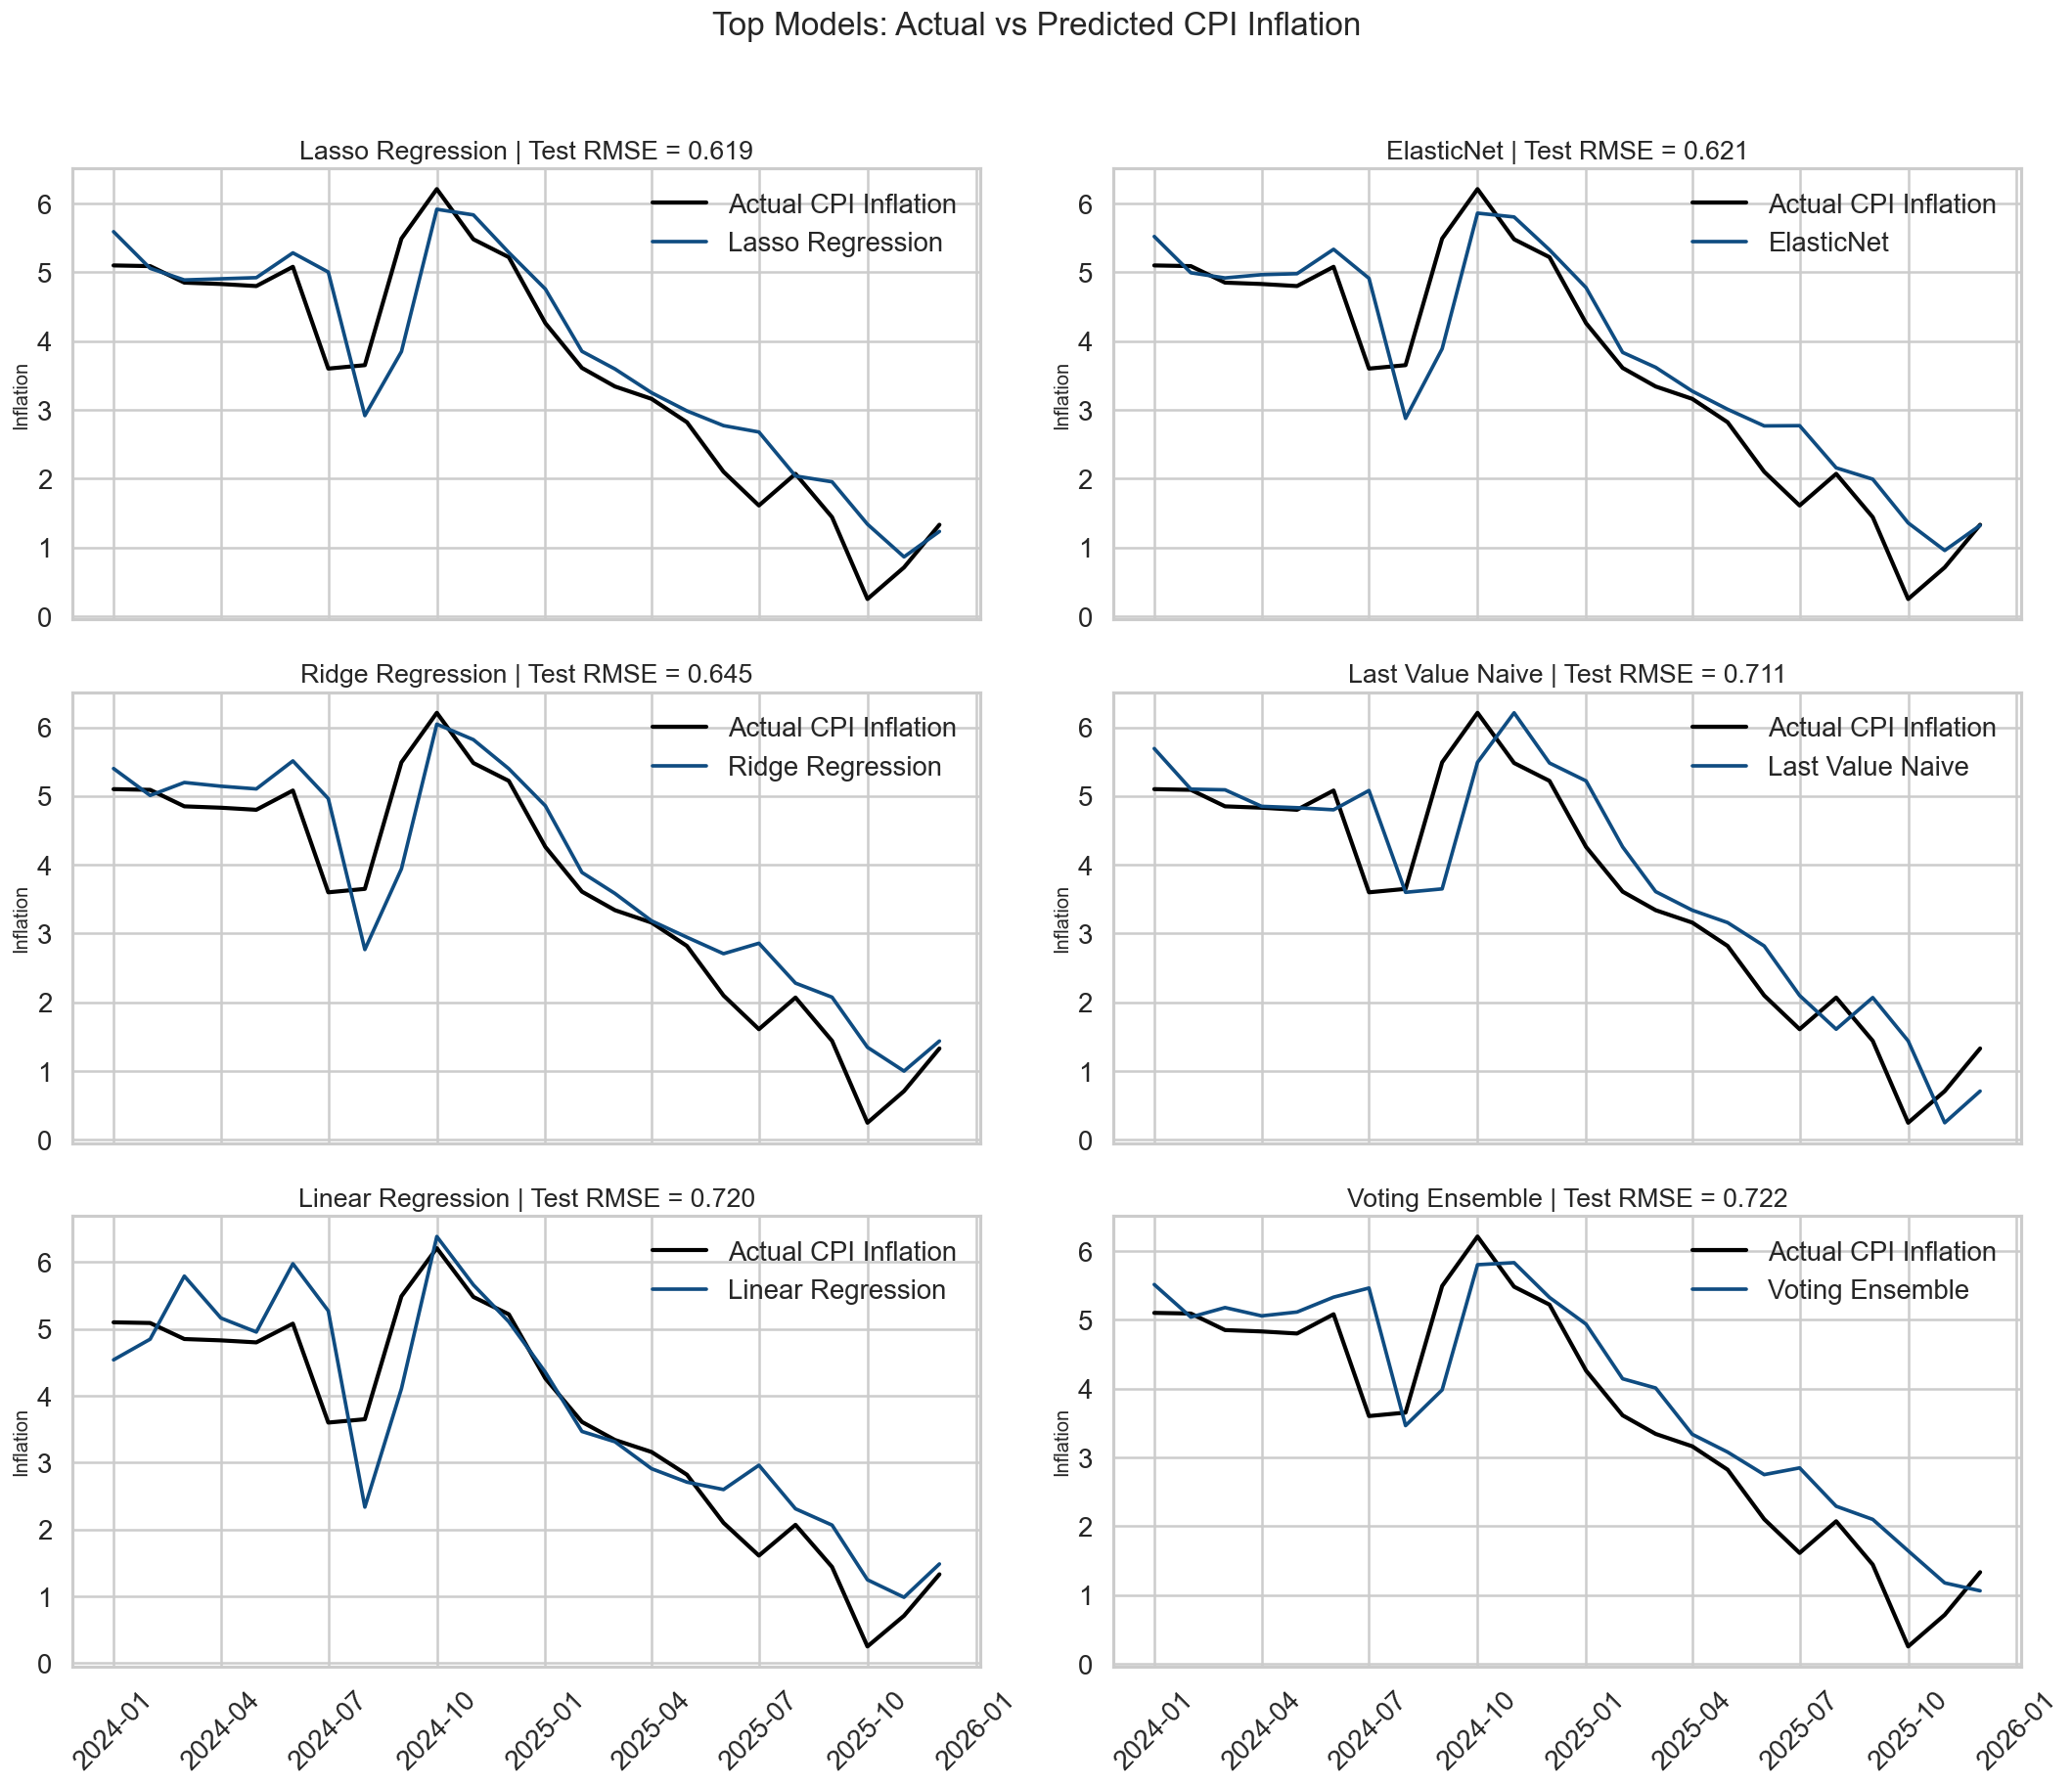

In [20]:

top_models = leaderboard['Model'].head(min(6, len(leaderboard))).tolist()
rows = int(np.ceil(len(top_models) / 2))
fig, axes = plt.subplots(rows, 2, figsize=(18, 5 * rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, model_name in zip(axes, top_models):
    pred_df = test_predictions[model_name]
    rmse_value = leaderboard.loc[leaderboard['Model'] == model_name, 'Test RMSE'].iloc[0]
    ax.plot(pred_df['Date'], pred_df['Actual'], color='black', linewidth=2.5, label='Actual CPI Inflation')
    ax.plot(pred_df['Date'], pred_df['Predicted'], color='#0f4c81', linewidth=2.2, label=model_name)
    ax.set_title(f'{model_name} | Test RMSE = {rmse_value:.3f}')
    ax.set_ylabel('Inflation')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

for ax in axes[len(top_models):]:
    ax.axis('off')

plt.suptitle('Top Models: Actual vs Predicted CPI Inflation', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


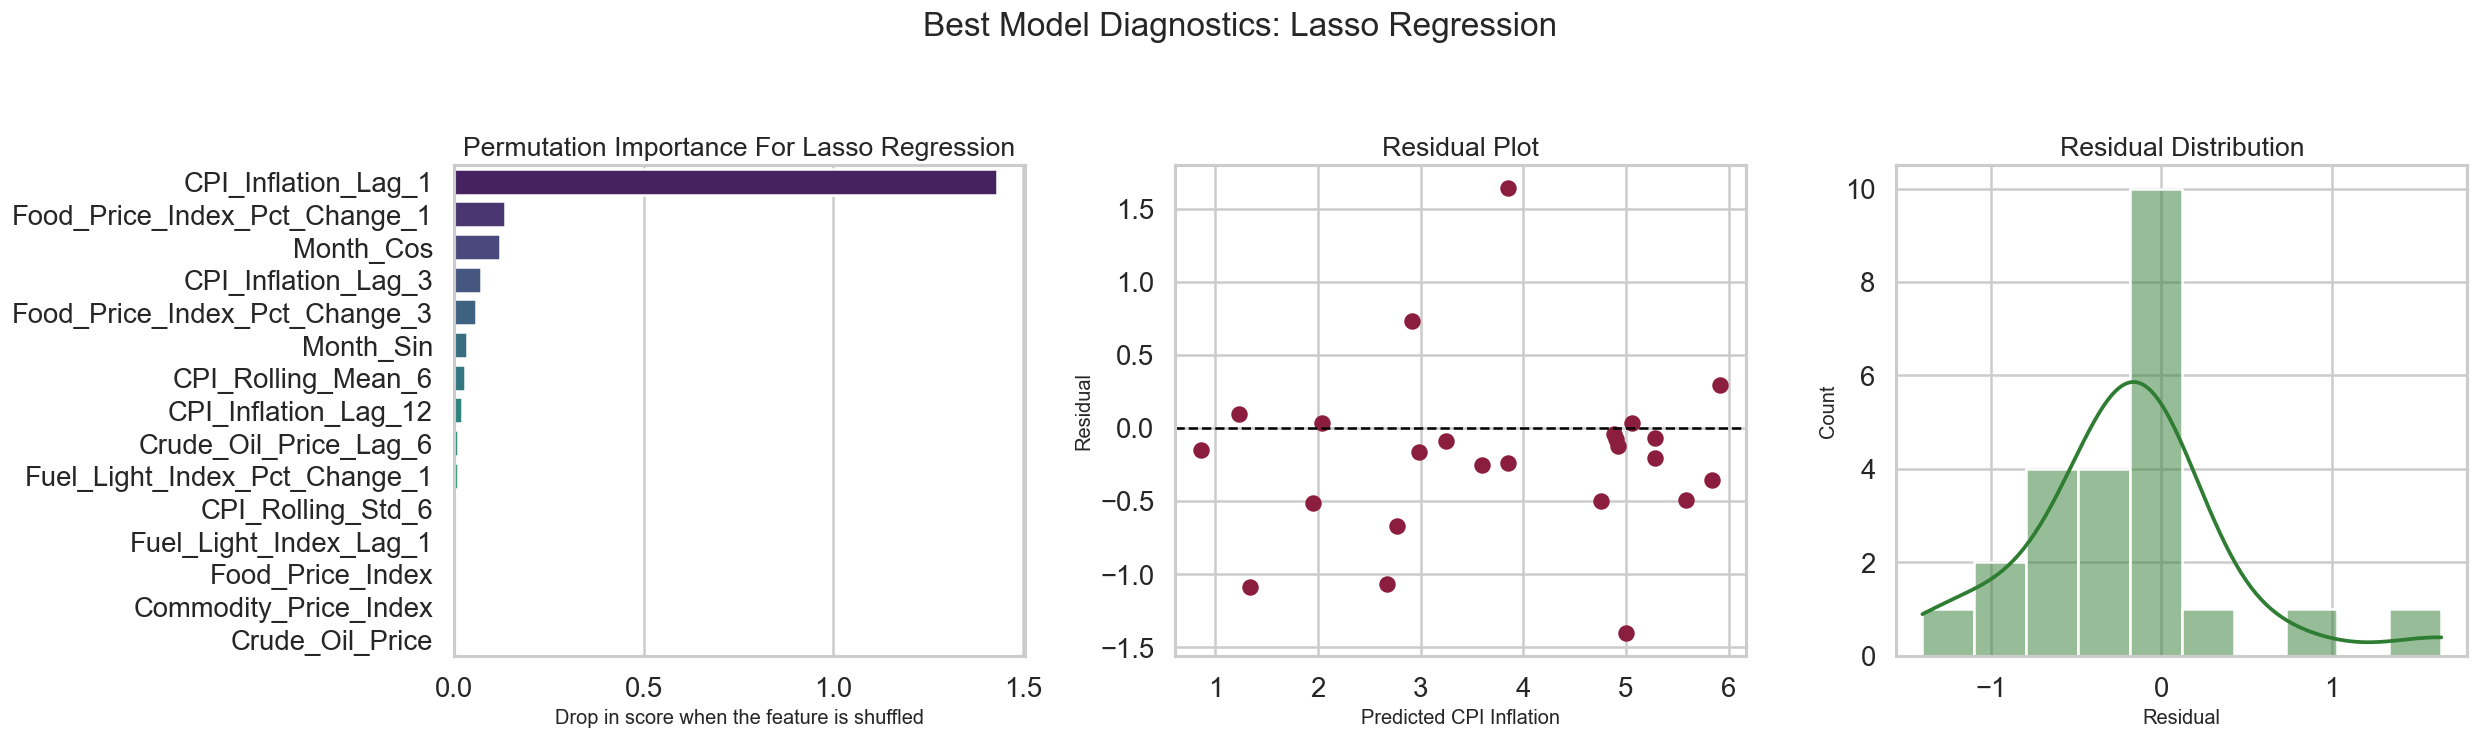

Best model on the holdout window: Lasso Regression


,Date,Actual,Predicted,Residual
144,2025-01-01,4.26,4.757,-0.497
145,2025-02-01,3.61,3.851,-0.241
146,2025-03-01,3.34,3.594,-0.254
147,2025-04-01,3.16,3.249,-0.089
148,2025-05-01,2.82,2.985,-0.165
149,2025-06-01,2.10,2.771,-0.671
150,2025-07-01,1.61,2.678,-1.068
151,2025-08-01,2.07,2.038,0.032
152,2025-09-01,1.44,1.954,-0.514
153,2025-10-01,0.25,1.338,-1.088


In [21]:

best_model_name = leaderboard.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_prediction_frame = test_predictions[best_model_name].copy()
best_prediction_frame['Residual'] = best_prediction_frame['Actual'] - best_prediction_frame['Predicted']

importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=20,
    random_state=42,
)
importance_df = (
    pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': importance.importances_mean,
    })
    .sort_values('Importance', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis', ax=axes[0])
axes[0].set_title(f'Permutation Importance For {best_model_name}')
axes[0].set_xlabel('Drop in score when the feature is shuffled')
axes[0].set_ylabel('')

axes[1].scatter(best_prediction_frame['Predicted'], best_prediction_frame['Residual'], color='#8b1e3f', s=70)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted CPI Inflation')
axes[1].set_ylabel('Residual')

sns.histplot(best_prediction_frame['Residual'], kde=True, color='#2f7d32', ax=axes[2])
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')

plt.suptitle(f'Best Model Diagnostics: {best_model_name}', fontsize=20, y=1.04)
plt.tight_layout()
plt.show()

print(f'Best model on the holdout window: {best_model_name}')
display(best_prediction_frame.tail(12).round(3))


In [22]:

leaderboard_export = leaderboard.copy()
leaderboard_export.to_csv(RESULTS_DIR / 'notebook_model_leaderboard.csv', index=False)

prediction_export = pd.concat(
    [frame.assign(Model=model_name) for model_name, frame in test_predictions.items()],
    ignore_index=True,
)
prediction_export.to_csv(RESULTS_DIR / 'notebook_test_predictions.csv', index=False)

cv_export = pd.concat(
    [frame.assign(Model=model_name) for model_name, frame in cv_results.items()],
    ignore_index=True,
)
cv_export.to_csv(RESULTS_DIR / 'notebook_cv_results.csv', index=False)

joblib.dump(best_model, RESULTS_DIR / 'notebook_best_model.pkl')

print('Saved artifacts:')
print(f"- {RESULTS_DIR / 'notebook_model_leaderboard.csv'}")
print(f"- {RESULTS_DIR / 'notebook_test_predictions.csv'}")
print(f"- {RESULTS_DIR / 'notebook_cv_results.csv'}")
print(f"- {RESULTS_DIR / 'notebook_best_model.pkl'}")


Saved artifacts:
- c:\Development\TSFA\TimeSeries\Mayur\results\notebook_model_leaderboard.csv
- c:\Development\TSFA\TimeSeries\Mayur\results\notebook_test_predictions.csv
- c:\Development\TSFA\TimeSeries\Mayur\results\notebook_cv_results.csv
- c:\Development\TSFA\TimeSeries\Mayur\results\notebook_best_model.pkl



## Final Takeaways

When you present this notebook, the main points are easy to explain:

- The task is treated as a true time-series problem, so the split is chronological instead of random.
- The final score is based on a **walk-forward one-step-ahead** holdout backtest rather than a random or shuffled split.
- The notebook uses the exact assignment variables as the predictor foundation.
- Feature engineering captures lag effects, momentum, and seasonality without leaking future data.
- The leaderboard compares simple baselines, linear models, and tree ensembles in one place.
- The final plots make it easy to explain not just which model won, but how each model behaves on the holdout window.

Why the Last Value Naive model is valid here:
- It predicts each month using the most recently observed CPI inflation.
- In a one-step-ahead monthly forecast, last month's CPI is known when you forecast the next month.

Why linear regression is not a straight line here:
- The model is linear in the features, not linear in time.
- Since food, fuel, crude oil, commodity, and lagged CPI features all move over time, the prediction line can bend too.

If you want to extend this even further later, the clean next steps are:
- add explicit hyperparameter tuning for the top 2 or 3 models only
- compare one-step-ahead versus recursive multi-step forecasting
- compare performance before and after adding extra macro variables outside the assignment scope
